In [2]:
import zipfile
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42

In [4]:
from pathlib import Path
import pandas as pd

columns = ['Id', 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']
file_path = Path('glass.data')
df = pd.read_csv(file_path, header=None, names=columns)
df.head()

,Id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [5]:
df.shape

(214, 11)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      214 non-null    int64  
 1   RI      214 non-null    float64
 2   Na      214 non-null    float64
 3   Mg      214 non-null    float64
 4   Al      214 non-null    float64
 5   Si      214 non-null    float64
 6   K       214 non-null    float64
 7   Ca      214 non-null    float64
 8   Ba      214 non-null    float64
 9   Fe      214 non-null    float64
 10  Type    214 non-null    int64  
dtypes: float64(9), int64(2)
memory usage: 18.5 KB


In [7]:
class_counts = df['Type'].value_counts().sort_index()
class_counts

Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64

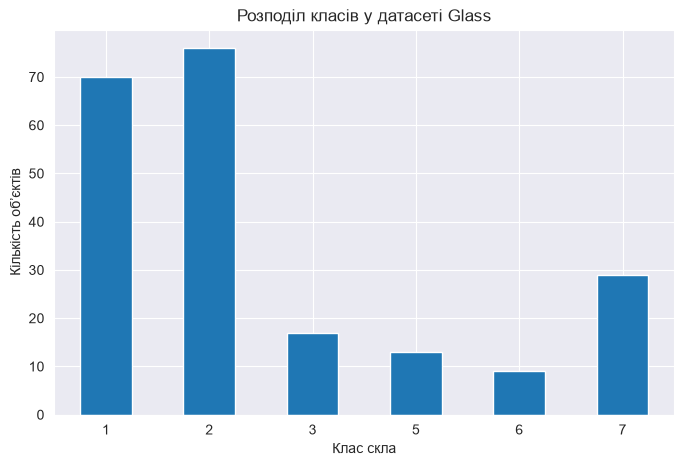

In [8]:
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar')
plt.title('Розподіл класів у датасеті Glass')
plt.xlabel('Клас скла')
plt.ylabel('Кількість об’єктів')
plt.xticks(rotation=0)
plt.show()

In [9]:
X = df.drop(columns=['Id', 'Type'])
y = df['Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (149, 9)
Test size: (65, 9)


In [10]:
print('Класи в train:')
print(y_train.value_counts().sort_index())
print('\nКласи в test:')
print(y_test.value_counts().sort_index())

Класи в train:
Type
1    49
2    53
3    12
5     9
6     6
7    20
Name: count, dtype: int64

Класи в test:
Type
1    21
2    23
3     5
5     4
6     3
7     9
Name: count, dtype: int64


In [11]:
baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
])

baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred_baseline))
print('Balanced accuracy:', balanced_accuracy_score(y_test, y_pred_baseline))
print('\nClassification report:')
print(classification_report(y_test, y_pred_baseline, zero_division=0))

Accuracy: 0.8153846153846154
Balanced accuracy: 0.7884000460087416

Classification report:
              precision    recall  f1-score   support

           1       0.77      0.95      0.85        21
           2       0.85      0.74      0.79        23
           3       1.00      0.40      0.57         5
           5       0.60      0.75      0.67         4
           6       0.75      1.00      0.86         3
           7       1.00      0.89      0.94         9

    accuracy                           0.82        65
   macro avg       0.83      0.79      0.78        65
weighted avg       0.84      0.82      0.81        65



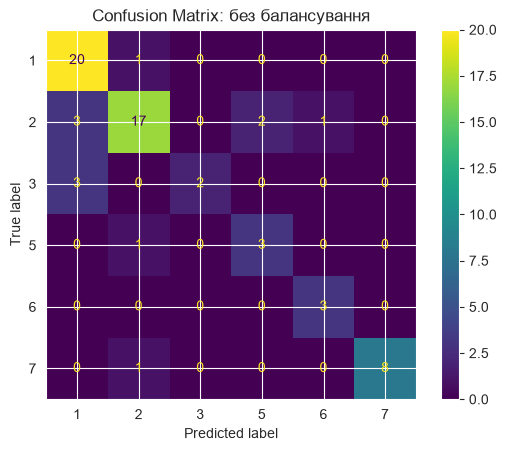

In [12]:
cm = confusion_matrix(y_test, y_pred_baseline, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot()
plt.title('Confusion Matrix: без балансування')
plt.show()

In [13]:
models = {
    'Без балансування': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
    ]),

    'class_weight=balanced': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ))
    ]),

    'RandomOverSampler': ImbPipeline([
        ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
    ]),

    'SMOTE': ImbPipeline([
        ('sampler', SMOTE(random_state=RANDOM_STATE, k_neighbors=2)),
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
    ])
}

In [17]:
results = []
reports = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    results.append({
        'Метод': name,
        'Accuracy': round(acc, 4),
        'Balanced accuracy': round(bal_acc, 4)
    })

    reports[name] = classification_report(y_test, y_pred, zero_division=0)

results_df = pd.DataFrame(results).sort_values(by='Balanced accuracy', ascending=False)
results_df

,Метод,Accuracy,Balanced accuracy
2,RandomOverSampler,0.8154,0.8482
1,class_weight=balanced,0.8154,0.8475
3,SMOTE,0.8154,0.8221
0,Без балансування,0.8154,0.7884


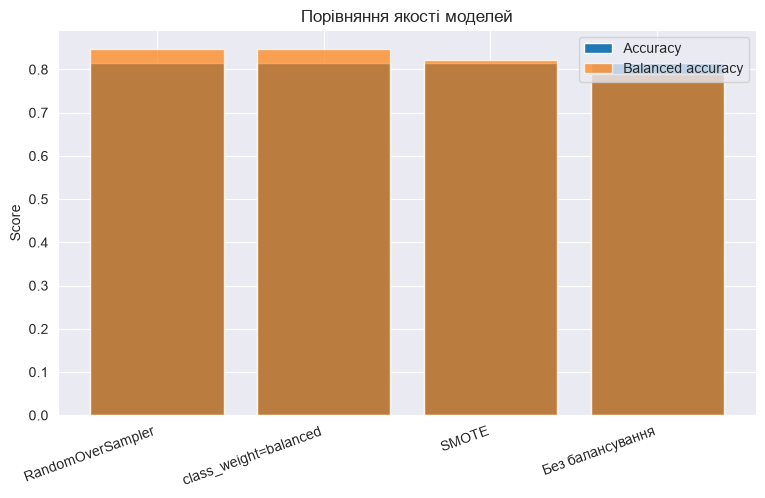

In [18]:
plt.figure(figsize=(9, 5))
plt.bar(results_df['Метод'], results_df['Accuracy'], label='Accuracy')
plt.bar(results_df['Метод'], results_df['Balanced accuracy'], alpha=0.7, label='Balanced accuracy')
plt.title('Порівняння якості моделей')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.legend()
plt.show()

In [19]:
for name, report in reports.items():
    print('=' * 60)
    print(name)
    print('=' * 60)
    print(report)

Без балансування
              precision    recall  f1-score   support

           1       0.77      0.95      0.85        21
           2       0.85      0.74      0.79        23
           3       1.00      0.40      0.57         5
           5       0.60      0.75      0.67         4
           6       0.75      1.00      0.86         3
           7       1.00      0.89      0.94         9

    accuracy                           0.82        65
   macro avg       0.83      0.79      0.78        65
weighted avg       0.84      0.82      0.81        65

class_weight=balanced
              precision    recall  f1-score   support

           1       0.86      0.86      0.86        21
           2       0.89      0.74      0.81        23
           3       0.43      0.60      0.50         5
           5       0.67      1.00      0.80         4
           6       0.75      1.00      0.86         3
           7       1.00      0.89      0.94         9

    accuracy                          

In [20]:
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

before_after = pd.DataFrame({
    'До балансування': y_train.value_counts().sort_index(),
    'Після RandomOverSampler': y_train_ros.value_counts().sort_index()
})
before_after

,До балансування,Після RandomOverSampler
Type,,
1,49,53
2,53,53
3,12,53
5,9,53
6,6,53
7,20,53


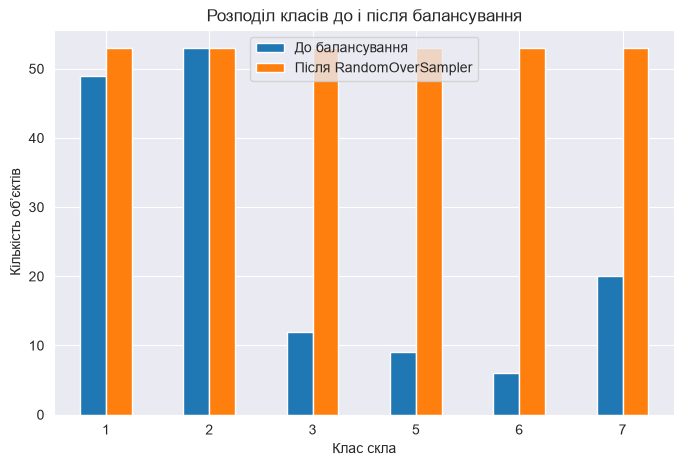

In [21]:
before_after.plot(kind='bar', figsize=(8, 5))
plt.title('Розподіл класів до і після балансування')
plt.xlabel('Клас скла')
plt.ylabel('Кількість об’єктів')
plt.xticks(rotation=0)
plt.show()